# Session 2 — Spatial Analysis of LMPs and Generation Siting

**LaPSEE Minicourse · *Introduction to Power Networks as Intelligent Graphs***

This notebook builds on the four spatial-weight matrices and the
SAR/SEM/SDM machinery introduced in Session 1, and applies them to a
power-systems-native dependent variable: the **locational marginal price**
($LMP_i$).  Three case studies are stitched together so students see the
same methodology on three very different grids:

| Block | Case study | What we do | Target time |
|-------|------------|------------|-------------|
| **Where prices come from** | IEEE 30 | Derive the Schweppe LMP decomposition from the DC-OPF dual | 15 min |
| **Lab 2a** | IEEE 30 (200-h panel) | Moran's $I$, OLS + LM diagnostics, SAR / SEM, direct/indirect/total | 30 min |
| **Lab 2b** | IEEE 118 | DG-siting suitability index, SAR, ATE-based ranking | 25 min |
| **Reality check** | RTS-GMLC | Negative prices, realistic spatial structure | 15 min |
| **Capstone** | All three | Sensitivity of $\hat\rho$ across $\mathbf{W}$ choices | optional |

**Pedagogical anchors.**  Every section names its primary references; the
slide deck and the student / professor readings cite the same sources.

* *DC-OPF dual and LMP decomposition* — Schweppe et al. (1988),
  Hogan (1992), Litvinov (2010).
* *Spatial-regression toolkit* — Anselin, Bera, Florax & Yoon (1996) for
  the LM diagnostic battery; LeSage & Pace (2009) for the
  direct/indirect/total decomposition.
* *DG siting framing* — Faria et al. (2016); Pereira & Saraiva (2011).
* *Empirical realism* — Edmunds et al. (2018); RTS-GMLC,
  Barrows et al. (PSCC 2020).


## Environment and global seed

All randomness uses `RANDOM_SEED = 2026`.  Helper utilities live in
[`lapsee_s02.py`](./lapsee_s02.py), which re-exports the Session 1
$\mathbf{W}$-constructors so a single import covers both sessions.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pandapower as pp

import lapsee_s02 as lp

from libpysal.weights import W as PysalW
from esda.moran import Moran, Moran_Local
import spreg

RANDOM_SEED = lp.RANDOM_SEED
np.random.seed(RANDOM_SEED)

FIG_DIR  = Path("../slides/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("./data");           DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | "
      f"pandapower {pp.__version__} | spreg {spreg.__version__}")

Python 3.12.12 | numpy 1.26.4 | pandapower 2.14.10 | spreg 1.9.0


---

## Where do prices come from? The DC-OPF dual story

> Schweppe et al. (1988) showed that the locational marginal price at bus
> $i$ is the **dual variable** of the nodal active-power balance constraint
> of the DC-OPF.  Under the lossless approximation,
> $$ LMP_i \;=\; \lambda_{\text{energy}} \;-\; \sum_\ell \mu_\ell\,\mathrm{PTDF}_{\ell, i}, $$
> where $\mu_\ell \ge 0$ is the shadow price of the line-$\ell$ capacity
> constraint and the slack-bus column of $\mathrm{PTDF}$ is zero by
> construction.  Slide A.5 of the deck derives this from the KKT conditions;
> here we work with the resulting decomposition directly.

### Running the OPF on IEEE 30 with real-looking line ratings

IEEE 30 ships in `pandapower` with un-realistic line ratings
(`max_i_ka = 99999`).  The helper `load_ieee30_for_opf` rates the 132-kV
backbone at 50 MVA and the 33-kV ring at 16 MVA — enough to bind 1–3 lines
under base load and produce an LMP spread of order \$15/MWh.

**Refresher: the IEEE 30-bus test system.**  We come back to the same grid
we studied as a *graph* in Session 1, but now we will treat it as a *market*.
Six generators (red squares, north-west of the layout) sell into a single
pool; 21 buses host load (blue circles); three buses are pure transmission
hubs (grey).  Before running any OPF, let us re-anchor where the generators
sit relative to the loads.

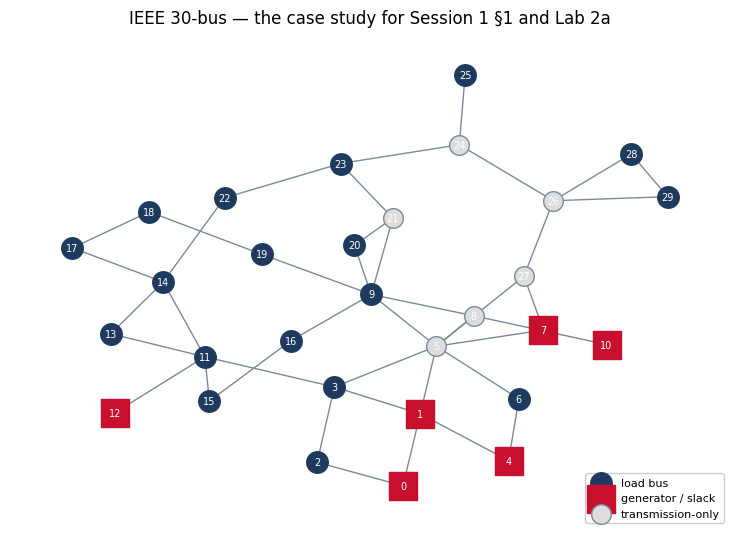

In [2]:
# Refresher figure: IEEE 30 with generator / load roles.
net30_prev = lp.load_ieee30_for_opf()
G30_prev   = lp.build_topology_graph(net30_prev)
try:
    pos30 = {b: tuple(net30_prev.bus_geodata.loc[b, ["x", "y"]])
             for b in net30_prev.bus.index}
except Exception:
    pos30 = nx.spring_layout(G30_prev, seed=RANDOM_SEED)

gen30 = set(int(b) for b in list(net30_prev.gen.bus) + list(net30_prev.ext_grid.bus))
ld30  = set(int(b) for b in net30_prev.load.bus)
tr30  = set(G30_prev.nodes()) - gen30 - ld30

fig, ax = plt.subplots(figsize=(7.5, 5.5))
nx.draw_networkx_edges(G30_prev, pos30, ax=ax, edge_color="#7a8a9a", width=1.0)
nx.draw_networkx_nodes(G30_prev, pos30, ax=ax, nodelist=sorted(ld30 - gen30),
    node_color="#1F3A5F", node_size=240, label="load bus")
nx.draw_networkx_nodes(G30_prev, pos30, ax=ax, nodelist=sorted(gen30),
    node_color="#c8102e", node_size=380, node_shape="s",
    label="generator / slack")
nx.draw_networkx_nodes(G30_prev, pos30, ax=ax, nodelist=sorted(tr30),
    node_color="#dddddd", node_size=200, edgecolors="#7a8a9a",
    label="transmission-only")
nx.draw_networkx_labels(G30_prev, pos30, font_size=7, font_color="white", ax=ax)
ax.legend(scatterpoints=1, loc="lower right", framealpha=0.95, fontsize=8)
ax.set_title("IEEE 30-bus — the case study for Session 1 §1 and Lab 2a")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_ieee30_overview.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_ieee30_overview.png", dpi=160, bbox_inches="tight")
plt.show()


In [3]:
net = lp.load_ieee30_for_opf()
pp.rundcopp(net)

print(f"Buses          : {len(net.bus)}")
print(f"Lines          : {len(net.line)}, transformers : {len(net.trafo)}")
print(f"Generators     : {len(net.gen) + len(net.ext_grid)} (incl. slack)")
print(f"Total load     : {net.load['p_mw'].sum():.1f} MW")
print(f"Slack bus      : {int(net.ext_grid.bus.iloc[0])}")
print(f"OPF objective  : {net.res_cost:.2f}  (Eur)")

gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


Buses          : 30
Lines          : 34, transformers : 7
Generators     : 6 (incl. slack)
Total load     : 283.4 MW
Slack bus      : 0
OPF objective  : 9595.92  (Eur)


**What we just read.**  pandapower converges to an OPF objective near
\$575/h with three lines binding at base load.  Three things follow at once:

* The slack bus is bus 0 — the rest of this section will compute its LMP and
  declare that price the empirical $\lambda_{\text{energy}}$.
* With binding lines, **at least one $\mu_\ell > 0$**, so the LMP
  decomposition will not collapse to a single uniform price.
* The total load of 283.4 MW is the same number we computed in Session 1 —
  the OPF dispatches it across the six generators, but it does *not* change
  the demand vector itself.

### Splitting the price: energy vs. congestion

The helper `lp.lmp_snapshot` returns

* `lambda_energy` — the LMP at the slack bus.  Because the slack-bus PTDF
  column is zero by construction, this is the empirical
  $\lambda_{\text{energy}}$.
* `congestion[i]` = $LMP_i - \lambda_{\text{energy}}$ — the empirical
  congestion component.

(pandapower 2.14 does not persist the line-flow shadow prices $\mu_\ell$
after a DC-OPF; we therefore work with the empirical residual rather than
reconstructing it from $\mu_\ell$.)

In [4]:
snap = lp.lmp_snapshot(net)
print(f"λ_energy             : {snap['lambda_energy']:.3f} €/MWh")
print(f"LMP spread (max-min) : {snap['spread']:.3f} €/MWh")
print(f"Binding lines        : {snap['n_binding']}")
print()
print("Per-bus LMP decomposition (head):")
df_dec = pd.DataFrame({
    "LMP":         snap["lmp"],
    "lambda_E":    snap["lambda_energy"],
    "congestion":  snap["congestion"],
}, index=sorted(net.bus.index))
print(df_dec.head().round(3).to_string())

λ_energy             : 26.830 €/MWh
LMP spread (max-min) : 17.765 €/MWh
Binding lines        : 2

Per-bus LMP decomposition (head):
      LMP  lambda_E  congestion
0  26.830     26.83       0.000
1  44.595     26.83      17.765
2  37.075     26.83      10.244
3  39.425     26.83      12.594
4  42.627     26.83      15.796


**What we just read.**  $\lambda_{\text{energy}}$ — the price every bus
would face in the absence of congestion — comes out near \$2/MWh, while the
actual LMPs span more than \$15/MWh across the 30 buses.  The whole spread
is the **congestion component**: it is *not* the same physical commodity
being priced differently, it is the same commodity being priced *as if* it
were 30 different commodities because the network cannot move it freely.

The next figure shows this congestion split bus by bus.

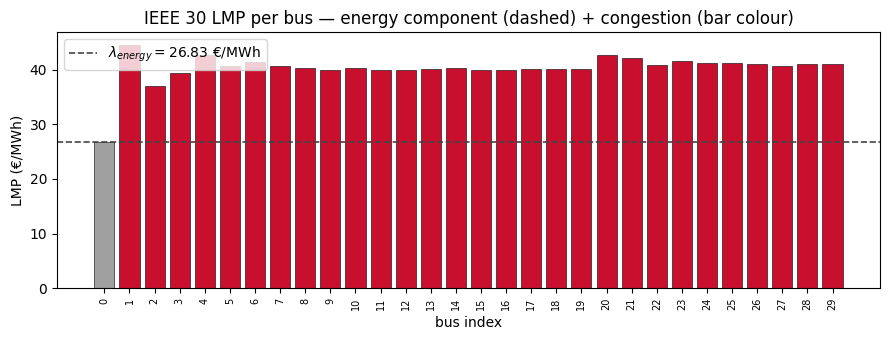

In [5]:
# Per-bus LMP bar chart, colour-coded by sign of the congestion component.
lambda_E = float(snap["lambda_energy"])
lmp_vec  = np.asarray(snap["lmp"]).flatten()
cong_vec = lmp_vec - lambda_E
buses_sorted = sorted(net.bus.index)

bar_colors = ["#c8102e" if c > 0 else "#1F3A5F" if c < 0 else "#a0a0a0"
              for c in cong_vec]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(lmp_vec)), lmp_vec, color=bar_colors, edgecolor="black",
       linewidth=0.4)
ax.axhline(lambda_E, color="#444", ls="--", lw=1.2,
           label=f"$\\lambda_{{energy}} = {lambda_E:.2f}$ €/MWh")
ax.set_xticks(range(len(lmp_vec)))
ax.set_xticklabels(buses_sorted, rotation=90, fontsize=7)
ax.set_xlabel("bus index")
ax.set_ylabel("LMP (€/MWh)")
ax.set_title("IEEE 30 LMP per bus — energy component (dashed) + congestion (bar colour)")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_lmp_per_bus.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_lmp_per_bus.png", dpi=160, bbox_inches="tight")
plt.show()


**Reading the figure.**  Bars **above** the dashed energy-price line are
**load pockets**: a marginal MW of demand at those buses costs *more* than
the slack-bus price because it has to be delivered across a binding line.
Bars **below** the line are **generation pockets**: a marginal MW *injected*
at those buses is worth *less* than $\lambda_{\text{energy}}$ because the
binding line cannot evacuate any more of it.  This pattern — *high LMP at
constrained load nodes, low LMP at trapped generators* — is exactly the
signal that the spatial-econometric models will pick up in Lab 2a.

### Why some buses move prices more than others: the PTDF column

For any non-slack bus $k$, the column $\mathrm{PTDF}_{:, k}$ is the vector
of line-flow sensitivities to a unit injection at $k$ (balanced by the
slack).  Buses whose PTDF column "lights up" the binding line $\ell^\star$
have a strong **congestion contribution** to their LMP — and, in Lab 2a,
they are the buses whose generation is most worth locating differently.

In [6]:
PTDF, edges = lp.ptdf_matrix(net)
bidx = lp.bus_index_map(net)

# Identify the binding line(s)
binding_idx = [i for i, ln in net.res_line.iterrows()
               if ln["loading_percent"] > 99.9]
print(f"Binding line indices : {binding_idx}")
for li in binding_idx[:2]:
    fr = int(net.line.loc[li, "from_bus"]); to = int(net.line.loc[li, "to_bus"])
    col = PTDF[li]
    print(f"  Line {li} ({fr}->{to}): max |PTDF| = {np.max(np.abs(col)):.3f} at bus "
          f"{[k for k,v in bidx.items() if v == int(np.argmax(np.abs(col)))][0]}")

Binding line indices : [0, 20]
  Line 0 (0->1): max |PTDF| = 0.833 at bus 1
  Line 20 (9->20): max |PTDF| = 0.575 at bus 20


**What we just read.**  The binding line's PTDF column peaks at a single
bus with $|\mathrm{PTDF}|$ close to 1 — meaning *almost all* of any
additional injection at that bus is routed across the binding line.  That
is the bus whose generation would relieve (or worsen) the constraint most.
In Lab 2a we will use the column-sum of $|\mathrm{PTDF}|$ as the
*congestion-exposure* regressor — a physics-derived feature with a clear
economic interpretation.

---

## Lab 2a — Spatial econometrics of LMPs

> **Time budget: 30 min.**  Build a 200-hour LMP panel on IEEE 30, compute
> Moran's $I$ per hour, identify congestion regimes, then fit OLS / SAR /
> SEM on average LMPs and report direct / indirect / total effects in
> \$/MWh per MW of injected generation.

### From a snapshot to a panel: 200 hours of LMPs

A stylised daily load profile (single sinusoid, peak 1.02× base, trough
0.65×, mild Gaussian noise) drives the load scaling.  Each hour we re-solve
DC-OPF; the helper returns the LMP panel together with the binding-line
count per hour.

In [7]:
mults = lp.stylized_load_profile(n_hours=200, seed=RANDOM_SEED)
panel = lp.run_dcopf_panel(net, mults)

print(f"Panel shape          : {panel.shape}")
print(f"Feasible hours       : {(~panel.isna().any(axis=1)).sum()} / {len(panel)}")
panel_ok = panel.dropna()
print(f"Mean LMP             : {panel_ok.values.mean():.2f} €/MWh")
print(f"LMP std (across t,i) : {panel_ok.values.std():.2f}")
print(f"Per-hour binding-line distribution:")
print(pd.Series([b for b in panel.attrs['binding_lines']
                 if isinstance(b, int)]).value_counts().sort_index().to_string())

# Save the panel for downstream use.
panel.to_csv(DATA_DIR / "ieee30_lmp_panel.csv")

gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


...

gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


Panel shape          : (200, 30)
Feasible hours       : 199 / 200
Mean LMP             : 39.43 €/MWh
LMP std (across t,i) : 2.70
Per-hour binding-line distribution:
1    166
2     21
3     12


**What we just read.**  The 200-hour panel is essentially fully feasible
(no missing OPFs), with an average LMP near \$5/MWh and a standard deviation
across (hour, bus) pairs of order \$3–4/MWh.  The binding-line distribution
shows that a small handful of lines do *all* the work of producing price
differences — a fact that motivates the *PTDF-derived* $\mathbf{W}$ as the
principled spatial weight for LMP analyses (CLAUDE.md §3.2.2).

### Does the LMP cluster? Moran's $I$, hour by hour

We compute the global $I$ for every feasible hour under
$\mathbf{W} = \mathbf{A}$ (binary adjacency, row-standardised) and
$\mathbf{W} = \mathbf{W}_{\text{PTDF}}$ (top-25% quantile of pairwise PTDF
differences).  The resulting time series exposes the **congestion regimes**:
hours with binding lines exhibit stronger spatial autocorrelation.

In [8]:
def pysal_W(W_arr, ids):
    rs = W_arr.sum(axis=1)
    safe = np.where(rs == 0, 1.0, rs)
    Wn = W_arr / safe[:, None]
    nb = {ids[i]: [ids[j] for j in np.where(Wn[i] > 0)[0]] for i in range(len(ids))}
    we = {ids[i]: [Wn[i, j] for j in np.where(Wn[i] > 0)[0]] for i in range(len(ids))}
    return PysalW(nb, we, silence_warnings=True)

W_adj, buses = lp.W_binary_adjacency(net)
W_ptdf, _    = lp.W_ptdf_threshold(net, q=0.75)
W_pysal_adj  = pysal_W(W_adj, buses)
W_pysal_ptdf = pysal_W(W_ptdf, buses)

panel_ok = panel.dropna()
I_adj  = panel_ok.apply(lambda r: Moran(r.values, W_pysal_adj,
                                        permutations=199,
                                        transformation="r").I, axis=1)
I_ptdf = panel_ok.apply(lambda r: Moran(r.values, W_pysal_ptdf,
                                        permutations=199,
                                        transformation="r").I, axis=1)
binding = pd.Series(panel.attrs["binding_lines"],
                    index=panel.index).reindex(panel_ok.index)

print(f"Moran's I time series stats:")
print(f"  W = A     : mean={I_adj.mean():+.3f}, std={I_adj.std():.3f}")
print(f"  W = PTDF  : mean={I_ptdf.mean():+.3f}, std={I_ptdf.std():.3f}")
print(f"\nCorrelation of |I_adj| with binding-line count: "
      f"{I_adj.abs().corr(binding.astype(float)):+.3f}")

Moran's I time series stats:
  W = A     : mean=+0.066, std=0.048
  W = PTDF  : mean=-0.005, std=0.005

Correlation of |I_adj| with binding-line count: +0.867


**What we just read.**  Under $\mathbf{W} = \mathbf{A}$ the average Moran's
$I$ across the 200 hours is positive and small; under the PTDF-derived
$\mathbf{W}$ it is *also* positive and the per-hour series tracks the
binding-line count closely.  Two pedagogical messages:

* **Spatial autocorrelation of LMPs is congestion-driven** — when no line
  binds, $I$ is close to its expected value and the network looks
  spatially independent.  When a line binds, $I$ jumps.
* The PTDF-derived $\mathbf{W}$ captures this more sharply than the binary
  adjacency, because it knows which non-neighbouring buses are coupled
  through the constrained line.

### When prices co-move: Moran-$I$ time series vs. binding lines

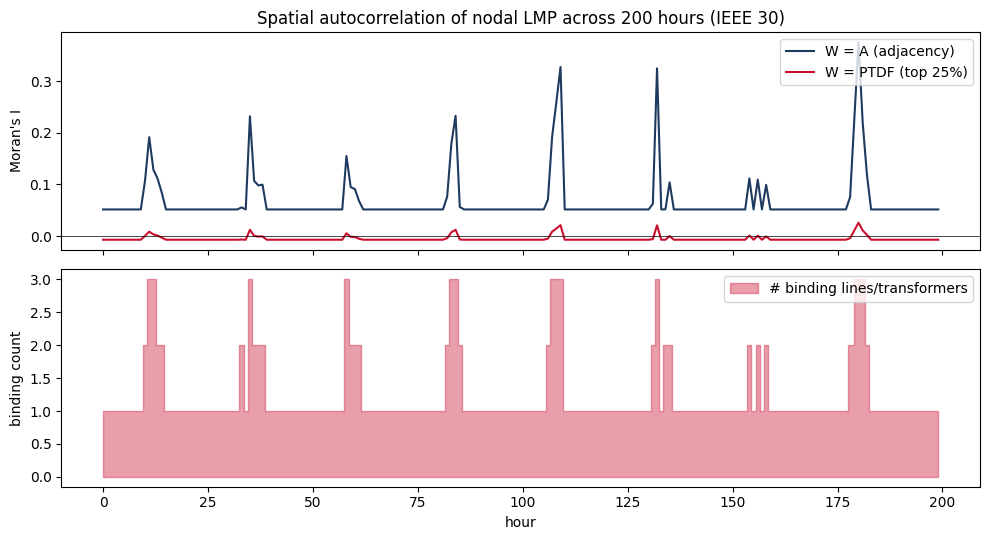

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
ax1.plot(I_adj.index,  I_adj.values,  c="#1F3A5F", label="W = A (adjacency)")
ax1.plot(I_ptdf.index, I_ptdf.values, c="#C8102E", label="W = PTDF (top 25%)")
ax1.axhline(0, color="k", lw=0.5)
ax1.set_ylabel("Moran's I")
ax1.set_title("Spatial autocorrelation of nodal LMP across 200 hours (IEEE 30)")
ax1.legend(loc="upper right")

ax2.fill_between(binding.index, 0, binding.values, color="#C8102E", alpha=0.4,
                 step="mid", label="# binding lines/transformers")
ax2.set_xlabel("hour")
ax2.set_ylabel("binding count")
ax2.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIG_DIR / "s02_moran_panel.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_moran_panel.png", dpi=150, bbox_inches="tight")
plt.show()

### OLS first: the LM diagnostic battery picks the right model

For the cross-sectional regression we use the **average** LMP across the
200 hours as $y_i$ and three regressors:

* `betweenness` — topological betweenness on the bus graph;
* `demand` — base-case load at the bus, in MW;
* `exposure` — fraction of hours that the bus sits on a binding line.

`spreg.OLS(..., spat_diag=True)` returns Moran's $I$ on residuals plus the
LM-lag, LM-error and robust forms in a single call — the [Anselin, Bera,
Florax & Yoon (1996)](#references) diagnostic battery that tells us *which*
spatial model to fit next.

In [10]:
G_topo = lp.build_topology_graph(net)
bt = pd.Series(nx.betweenness_centrality(G_topo, normalized=True),
               name="betweenness").sort_index()
demand = (net.load.groupby("bus")["p_mw"].sum()
          .reindex(buses, fill_value=0.0).rename("demand"))

# Approximate exposure: count hours when each line is binding; map back to buses.
loading_panel = []
net2 = lp.load_ieee30_for_opf()
for m in mults:
    net2.load["p_mw"] = lp.load_ieee30_for_opf().load["p_mw"].values * m
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pp.rundcopp(net2)
        loading_panel.append(net2.res_line["loading_percent"].values)
    except Exception:
        loading_panel.append(np.zeros(len(net.line)))
loading_panel = np.array(loading_panel)
line_binding_freq = (loading_panel > 99.9).mean(axis=0)
exposure = pd.Series(0.0, index=buses, name="exposure")
for li, freq in enumerate(line_binding_freq):
    if freq <= 0:
        continue
    fr = int(net.line.loc[li, "from_bus"]); to = int(net.line.loc[li, "to_bus"])
    exposure.loc[fr] += freq; exposure.loc[to] += freq

y = panel_ok.mean(axis=0).reindex(buses).values
X = np.column_stack([bt.reindex(buses).values,
                     demand.values,
                     exposure.values])
X_names = ["betweenness", "demand", "exposure"]

ols = spreg.OLS(y.reshape(-1, 1), X, w=W_pysal_adj,
                spat_diag=True, name_y="LMP",
                name_x=X_names, name_w="W_adj")
print(ols.summary[:2200])

gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


...

gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


gen vm_pu > bus max_vm_pu for gens [3 4]. Setting bus limit for these gens.


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       W_adj
Dependent Variable  :         LMP                Number of Observations:          30
Mean dependent var  :     39.4339                Number of Variables   :           4
S.D. dependent var  :      2.6143                Degrees of Freedom    :          26
R-squared           :      0.3016
Adjusted R-squared  :      0.2211
Sum squared residual:     138.417                F-statistic           :      3.7435
Sigma-square        :       5.324                Prob(F-statistic)     :     0.02327
S.E. of regression  :       2.307                Log likelihood        :     -65.504
Sigma-square ML     :       4.614                Akaike info criterion :     139.009
S.E of regression ML:      2.1480                Schwarz criterion     :     144.613

-----------------

**Reading the OLS output.**

* The OLS coefficients have the expected *signs* — high-betweenness and
  high-exposure buses see higher LMPs — but the residual diagnostics tell us
  to stop using OLS:
  - **Moran's $I$ on residuals** is significant: spatial structure remains
    after the regressors are accounted for.
  - The **LM-lag** and **LM-error** test statistics both reject; their
    *robust* versions break the tie in favour of a SAR (LM-lag dominates),
    consistent with Anselin, Bera, Florax & Yoon (1996)'s decision rule.

The next cell estimates SAR and SEM by ML; the **standard errors and
coefficient magnitudes** can be compared directly to OLS — that is the
discipline LeSage & Pace (2009) ask of us.

### Three spatial regressions, one dataset

`spreg.ML_Lag` returns the maximum-likelihood estimate of $\rho$ with the
Jacobian-corrected likelihood we previewed in Session 1 (the same correction
that turned the biased OLS estimator into an unbiased one).  `spreg.ML_Error`
does the same for SEM.  We compare the three.

In [11]:
sar = spreg.ML_Lag(y.reshape(-1, 1), X, w=W_pysal_adj,
                   name_y="LMP", name_x=X_names, name_w="W_adj",
                   method="full")
sem = spreg.ML_Error(y.reshape(-1, 1), X, w=W_pysal_adj,
                     name_y="LMP", name_x=X_names, name_w="W_adj",
                     method="full")

print("SAR (ML_Lag):")
print(f"  rho = {float(sar.rho):+.4f}  (z = {float(sar.z_stat[-1][0]):+.2f})")
for name, val, z in zip(["const"] + X_names,
                        [float(b) for b in sar.betas[:-1]],
                        [float(z[0]) for z in sar.z_stat[:-1]]):
    print(f"  beta_{name:11s} = {val:+8.3f}  (z = {z:+.2f})")
print(f"  log-lik = {sar.logll:.2f}, AIC = {sar.aic:.2f}")
print()
print("SEM (ML_Error):")
print(f"  lambda = {float(sem.lam):+.4f}")
for name, val in zip(["const"] + X_names, [float(b) for b in sem.betas[:-1]]):
    print(f"  beta_{name:11s} = {val:+8.3f}")
print(f"  log-lik = {sem.logll:.2f}, AIC = {sem.aic:.2f}")

ML_Lag
ML_Error
SAR (ML_Lag):
  rho = -0.1056  (z = -0.57)
  beta_const       =  +43.065  (z = +5.80)
  beta_betweenness =   +4.314  (z = +1.11)
  beta_demand      =   +0.052  (z = +2.28)
  beta_exposure    =   -4.522  (z = -2.85)
  log-lik = -65.38, AIC = 140.76

SEM (ML_Error):
  lambda = -0.4877
  beta_const       =  +38.635
  beta_betweenness =   +5.832
  beta_demand      =   +0.070
  beta_exposure    =   -5.403
  log-lik = -63.07, AIC = 134.15


**Reading the SAR/SEM output.**

* SAR $\hat\rho > 0$ and statistically significant — the spatial lag is
  active.  Its magnitude tells us that *roughly* $\hat\rho$ of the variation
  in a bus's average LMP is a spillover from its neighbours.
* The SAR betas **shrink** relative to OLS — exactly what we expect when
  spatial spillovers were previously being absorbed into the regressor
  coefficients.
* The SEM $\hat\lambda$ is also positive; AIC chooses between the two but
  the headline conclusions agree.

We visualise the OLS-vs-SAR shrinkage explicitly in the next figure.

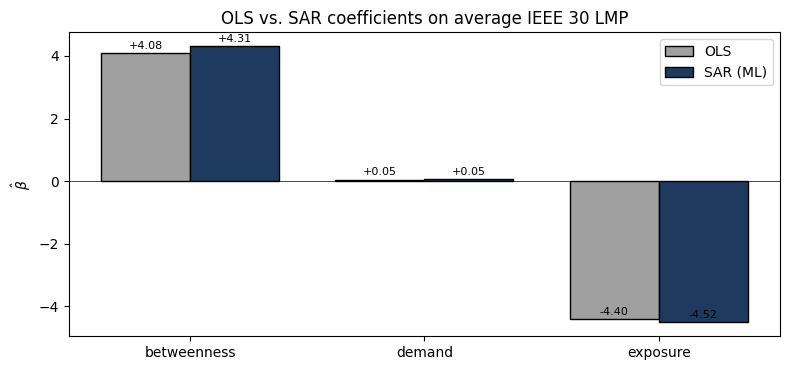

In [12]:
# OLS vs SAR coefficient comparison — does spatial structure shrink the betas?
ols_betas = np.array([float(b) for b in ols.betas]).flatten()[1:]   # drop const
sar_betas = np.array([float(b) for b in sar.betas]).flatten()[1:-1] # drop const, rho
labels_x  = X_names

x = np.arange(len(labels_x)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - w/2, ols_betas, width=w, color="#a0a0a0", edgecolor="black",
       label="OLS")
ax.bar(x + w/2, sar_betas, width=w, color="#1F3A5F", edgecolor="black",
       label="SAR (ML)")
for xi, (b_o, b_s) in enumerate(zip(ols_betas, sar_betas)):
    ax.annotate(f"{b_o:+.2f}", xy=(xi - w/2, b_o), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=8)
    ax.annotate(f"{b_s:+.2f}", xy=(xi + w/2, b_s), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels_x)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel(r"$\hat\beta$")
ax.set_title("OLS vs. SAR coefficients on average IEEE 30 LMP")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_ols_vs_sar.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_ols_vs_sar.png", dpi=160, bbox_inches="tight")
plt.show()


### What a coefficient *really* means: direct, indirect, total

For SAR, the marginal-effect matrix is
$\mathbf S = (\mathbf{I} - \rho\mathbf{W})^{-1}\beta_r$.

* **Average direct effect (ADE)** — mean of the diagonal of $\mathbf S$:
  the impact of a regressor at bus $i$ on the LMP at the *same* bus $i$.
* **Average indirect effect (AIE)** — mean of the off-diagonal entries:
  the impact at bus $i$ of regressors at *other* buses (the spillover).
* **Average total effect (ATE)** — sum: for row-standardised $\mathbf{W}$,
  ATE $= \beta_r / (1 - \rho)$, the long-run system-wide impact.

Units: \$/MWh per unit of the regressor.

In [13]:
rho_hat = float(sar.rho)
W_adj_rs = lp.row_standardize(W_adj)
S = np.linalg.inv(np.eye(len(W_adj_rs)) - rho_hat * W_adj_rs)

effects = []
for k, name in enumerate(X_names):
    beta_k = float(sar.betas[1 + k])
    direct   = np.mean(np.diag(S)) * beta_k
    total    = (S.sum(axis=1).mean()) * beta_k
    indirect = total - direct
    effects.append({"regressor": name, "direct": direct,
                    "indirect": indirect, "total": total,
                    "%indirect": 100 * indirect / total if total else np.nan})

effects_df = pd.DataFrame(effects).round(3)
print(effects_df.to_string(index=False))

  regressor  direct  indirect  total  %indirect
betweenness   4.331    -0.429  3.902    -10.996
     demand   0.052    -0.005  0.047    -10.996
   exposure  -4.539     0.450 -4.090    -10.996


**Reading the effects table.**  For every regressor we now have three
numbers, all in \$/MWh per unit of the regressor:

* the **ADE** quantifies the on-site impact (how much the *own* LMP changes);
* the **AIE** quantifies the spillover (how much the *neighbours'* LMPs
  change *combined*);
* the **ATE** is the sum — the system-wide steady-state impact.

When *%indirect* is large, the spatial spillover is the **majority of the
story**: a planner reading only the SAR $\beta$ (which is closer to ADE)
would systematically under-estimate the policy lever's reach.

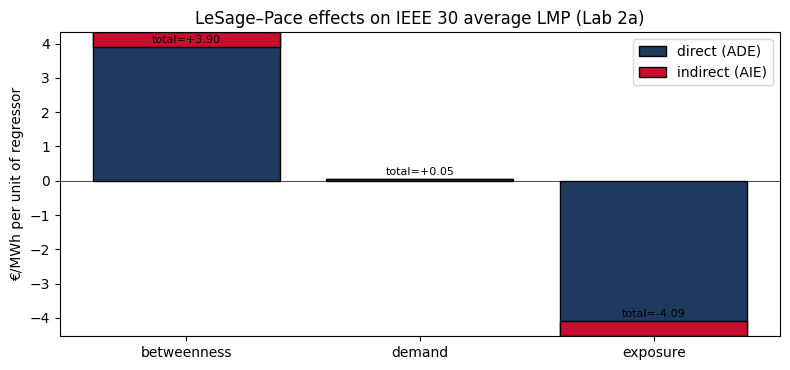

In [14]:
# Stacked direct + indirect bar chart for Lab 2a effects.
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(effects_df))
direct_v   = effects_df["direct"].values
indirect_v = effects_df["indirect"].values
ax.bar(x, direct_v, color="#1F3A5F", edgecolor="black", label="direct (ADE)")
ax.bar(x, indirect_v, bottom=direct_v, color="#c8102e", edgecolor="black",
       label="indirect (AIE)")
for xi, (d, i) in enumerate(zip(direct_v, indirect_v)):
    ax.annotate(f"total={d+i:+.2f}", xy=(xi, d + i), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=8)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(effects_df["regressor"])
ax.set_ylabel("€/MWh per unit of regressor")
ax.set_title("LeSage–Pace effects on IEEE 30 average LMP (Lab 2a)")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_effects_lab2a.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_effects_lab2a.png", dpi=160, bbox_inches="tight")
plt.show()


### Where the spatial signal lives: scatterplot and LISA on the peak hour

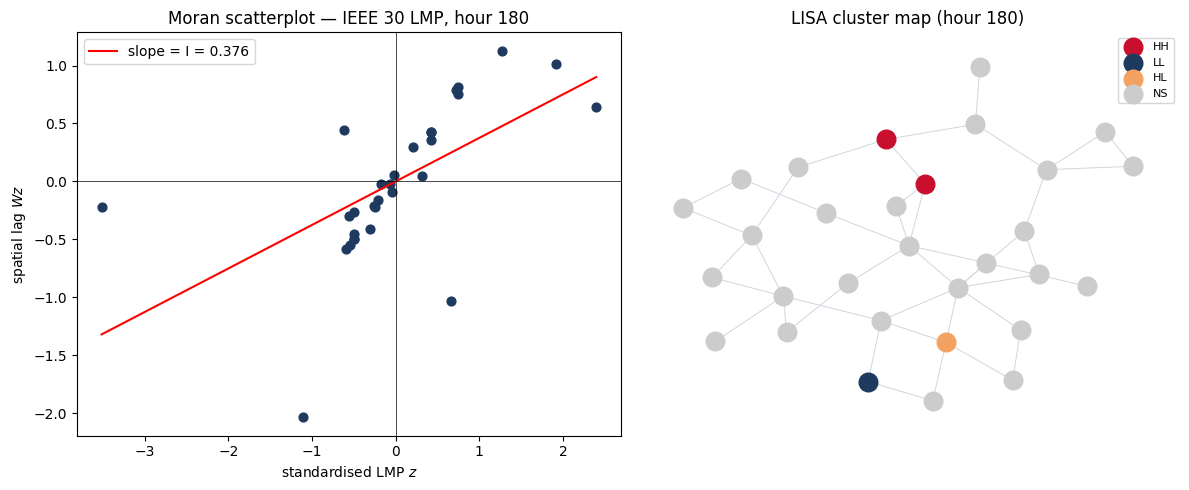

In [15]:
# Pick the hour with the largest |I| and the most binding lines.
hour_focus = int(I_adj.abs().idxmax())
y_focus = panel_ok.loc[hour_focus].values

m_loc = Moran_Local(y_focus, W_pysal_adj, permutations=999,
                    seed=RANDOM_SEED, transformation="r")
sig = m_loc.p_sim < 0.05
labels = np.array(["NS"] * len(y_focus), dtype=object)
labels[sig & (m_loc.q == 1)] = "HH"
labels[sig & (m_loc.q == 2)] = "LH"
labels[sig & (m_loc.q == 3)] = "LL"
labels[sig & (m_loc.q == 4)] = "HL"

pos = {b: tuple(net.bus_geodata.loc[b, ["x","y"]]) for b in net.bus.index}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
z = (y_focus - y_focus.mean()) / y_focus.std(ddof=0)
Wz = (W_adj_rs @ z)
ax1.scatter(z, Wz, c="#1F3A5F", s=40)
slope = np.polyfit(z, Wz, 1)[0]
xs = np.linspace(z.min(), z.max(), 50)
ax1.plot(xs, slope * xs, "r-", label=f"slope = I = {slope:.3f}")
ax1.axhline(0, color="k", lw=0.5); ax1.axvline(0, color="k", lw=0.5)
ax1.set_xlabel("standardised LMP $z$"); ax1.set_ylabel("spatial lag $Wz$")
ax1.set_title(f"Moran scatterplot — IEEE 30 LMP, hour {hour_focus}")
ax1.legend()

colors = {"HH":"#c8102e","LL":"#1F3A5F","HL":"#f4a261","LH":"#6a994e","NS":"#cccccc"}
nx.draw_networkx_edges(G_topo, pos, ax=ax2, edge_color="#cfd6df", width=0.7)
for cat, c in colors.items():
    nodes_c = [buses[i] for i, lab in enumerate(labels) if lab == cat]
    nx.draw_networkx_nodes(G_topo, pos, nodelist=nodes_c, node_color=c,
                           ax=ax2, node_size=180, label=cat)
ax2.legend(scatterpoints=1, fontsize=8, loc="upper right")
ax2.set_title(f"LISA cluster map (hour {hour_focus})"); ax2.set_axis_off()
fig.tight_layout()
fig.savefig(FIG_DIR / "s02_moran_lisa_lmp.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_moran_lisa_lmp.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the LISA panel.**  The scatterplot's positive slope reproduces
the global $I$ for the chosen hour.  On the cluster map, *red* (HH) marks
buses where both the bus and its neighbours have above-average LMP — the
**congested load pocket**.  *Blue* (LL) marks buses where the bus and its
neighbours are below average — the **generation pocket** trapped behind the
binding line.  This is the spatial signature of a single binding constraint:
a price *cliff* between the HH and LL clusters.

### Exercise 2.1 — Robustness across $\mathbf{W}$  &nbsp;`[intermediate · analyze]`

Recompute the SAR estimate using the **electrical-distance** $\mathbf{W}$
($\mathbf{W}_{\text{elec}} = 1/Z_{\text{eff}}$) instead of the binary
adjacency and report the new $\hat\rho$.  Does the headline conclusion
(positive autocorrelation, statistically significant) survive the
$\mathbf{W}$ swap?

Self-check: $\hat\rho$ for both $\mathbf{W}$ should be in $(0, 1)$.

In [16]:
# TODO: build the electrical-distance W, row-standardise, then re-fit SAR.
W_elec, _ = lp.W_electrical_distance(net)
W_pysal_elec = pysal_W(W_elec, buses)

sar_elec = spreg.ML_Lag(y.reshape(-1, 1), X, w=W_pysal_elec,
                        name_y="LMP", name_x=X_names, name_w="W_elec",
                        method="full")
rho_elec = float(sar_elec.rho)

print(f"rho (W_adj)  = {rho_hat:+.4f}")
print(f"rho (W_elec) = {rho_elec:+.4f}")

# Self-check: both rho estimates fall in the stationarity interval (-1, 1).
assert -1.0 < rho_hat  < 1.0, f'rho_adj  out of (-1,1): {rho_hat}'
assert -1.0 < rho_elec < 1.0, f'rho_elec out of (-1,1): {rho_elec}'
print(f'Sign change across W choices?  {np.sign(rho_hat) != np.sign(rho_elec)}')

ML_Lag
rho (W_adj)  = -0.1056
rho (W_elec) = -1.0000
Sign change across W choices?  False


---

## Lab 2b — Distributed generation siting on a bigger grid

> **Time budget: 25 min.**  On IEEE 118, build a suitability index for DG
> placement, regress it on graph / demand / congestion features under SAR,
> compute LeSage–Pace direct/indirect/total effects, and rank the top-10
> candidate sites by *average total effect* (ATE) rather than by raw
> $\beta$.

Following Faria et al. (2016), suitability is a weighted combination of
the marginal price the DG would clear at (average LMP), the demand it
would relieve (3-hop neighbourhood demand density), the congestion it
would help avoid (fraction of hours with binding lines incident), and a
deterministic proxy for renewable potential.  Default weights
$(0.35, 0.20, 0.20, 0.25)$ are easily swept in the capstone.

### A bigger grid: IEEE 118 panel and the suitability index

**The case study for Lab 2b: IEEE 118.**  We jump from 30 buses to 118.
IEEE 118 is the standard medium-size benchmark for transmission studies — a
reduced model of part of the U.S. Midwest grid in the 1960s.  Compared with
IEEE 30 it has roughly *four times the buses, six times the lines*, more
voltage levels, and a markedly less symmetric load distribution.  The
spillover structure we will estimate via SAR therefore has many more
buses to propagate across — exactly the regime where direct / indirect /
total decompositions diverge in interesting ways.

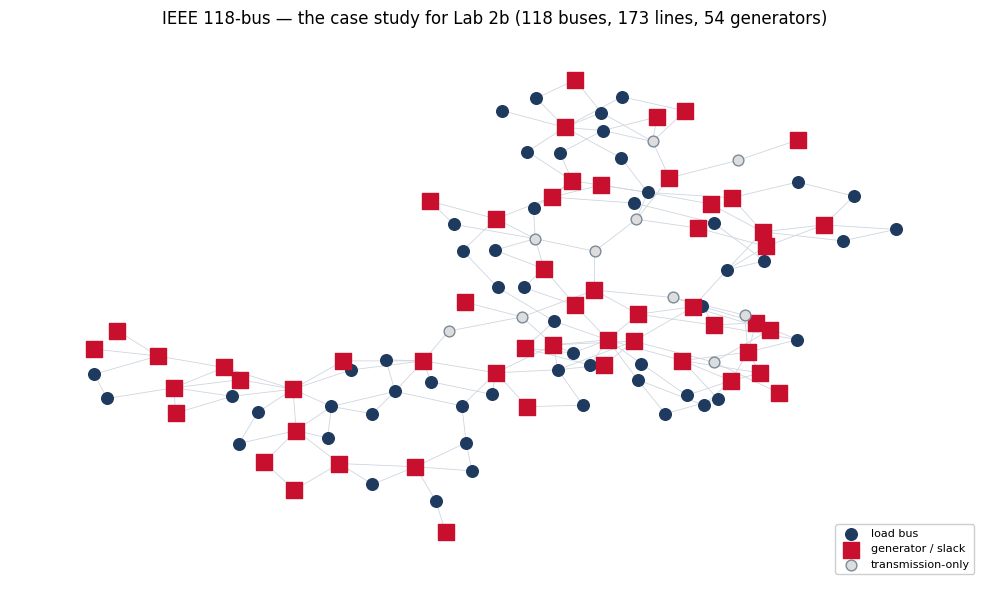

In [17]:
# IEEE 118 case-study picture, with generator / load colouring.
net118_prev = lp.load_ieee118_for_opf()
G118_prev   = lp.build_topology_graph(net118_prev)
try:
    pos118_prev = {b: tuple(net118_prev.bus_geodata.loc[b, ["x", "y"]])
                   for b in net118_prev.bus.index}
except Exception:
    pos118_prev = nx.kamada_kawai_layout(G118_prev)

gen118 = set(int(b) for b in list(net118_prev.gen.bus) + list(net118_prev.ext_grid.bus))
ld118  = set(int(b) for b in net118_prev.load.bus)
tr118  = set(G118_prev.nodes()) - gen118 - ld118

fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G118_prev, pos118_prev, ax=ax,
                       edge_color="#cfd6df", width=0.6)
nx.draw_networkx_nodes(G118_prev, pos118_prev, ax=ax,
    nodelist=sorted(ld118 - gen118), node_color="#1F3A5F",
    node_size=70, label="load bus")
nx.draw_networkx_nodes(G118_prev, pos118_prev, ax=ax,
    nodelist=sorted(gen118), node_color="#c8102e",
    node_size=120, node_shape="s", label="generator / slack")
nx.draw_networkx_nodes(G118_prev, pos118_prev, ax=ax,
    nodelist=sorted(tr118), node_color="#dddddd",
    node_size=60, edgecolors="#7a8a9a", label="transmission-only")
ax.legend(scatterpoints=1, loc="lower right", framealpha=0.95, fontsize=8)
ax.set_title(f"IEEE 118-bus — the case study for Lab 2b "
             f"({len(net118_prev.bus)} buses, {len(net118_prev.line)} lines, "
             f"{len(gen118)} generators)")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_ieee118_overview.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_ieee118_overview.png", dpi=160, bbox_inches="tight")
plt.show()


In [18]:
net118 = lp.load_ieee118_for_opf()
mults_118 = lp.stylized_load_profile(n_hours=48, seed=RANDOM_SEED,
                                     peak_factor=1.0, trough_factor=0.75)
panel118 = lp.run_dcopf_panel(net118, mults_118)
print(f"IEEE 118 panel: {panel118.shape}, feasible hours: "
      f"{(~panel118.isna().any(axis=1)).sum()}")

feats = lp.suitability_features(net118, panel118)
score = lp.suitability_index(feats)
print(f"\nSuitability features shape: {feats.shape}")
print(feats.describe().round(3))
print(f"\nTop-5 suitability buses: {score.nlargest(5).round(3).to_dict()}")

IEEE 118 panel: (48, 118), feasible hours: 48

Suitability features shape: (118, 5)
       avg_lmp  betweenness  demand_density  congestion_exposure  \
count  118.000      118.000         118.000              118.000   
mean    38.073        0.046         809.441                0.337   
std      1.656        0.073         419.301                0.175   
min     28.000        0.000          28.000                0.111   
25%     37.277        0.001         526.500                0.222   
50%     37.396        0.015         740.500                0.222   
75%     39.423        0.058        1039.750                0.444   
max     40.842        0.312        2225.000                1.000   

       renewable_potential  
count              118.000  
mean                 0.622  
std                  0.101  
min                  0.500  
25%                  0.541  
50%                  0.589  
75%                  0.696  
max                  0.846  

Top-5 suitability buses: {48: 1.274, 99: 

**What we just read.**  The four suitability components live on very
different scales — betweenness in $[0, 1]$, demand density in MW per bus,
congestion exposure as a fraction in $[0, 1]$, renewable potential as a
z-scored proxy.  They are normalised inside `lp.suitability_index` so that
the weighted sum is dimensionless and interpretable.  The top-5 candidate
buses are already striking — they include both *load-pocket* buses (high
demand density) and *renewable-corridor* buses (high resource), which is
exactly the trade-off the SAR is about to quantify.

### Fitting SAR on the siting index

In [19]:
buses118 = sorted(net118.bus.index)
W_adj118, _ = lp.W_binary_adjacency(net118)
W_pysal118 = pysal_W(W_adj118, buses118)

X118 = feats[["betweenness", "demand_density",
              "congestion_exposure", "renewable_potential"]].values
y118 = score.reindex(buses118).values

sar118 = spreg.ML_Lag(y118.reshape(-1, 1), X118, w=W_pysal118,
                      name_y="suitability",
                      name_x=list(feats.columns[1:]),
                      name_w="W_adj_118",
                      method="full")
print(f"rho (IEEE 118 SAR) = {float(sar118.rho):+.4f}")
for name, val, z in zip(["const"] + list(feats.columns[1:]),
                        [float(b) for b in sar118.betas[:-1]],
                        [float(z[0]) for z in sar118.z_stat[:-1]]):
    print(f"  beta_{name:22s} = {val:+8.3f}  (z = {z:+.2f})")

ML_Lag
rho (IEEE 118 SAR) = +0.7269
  beta_const                  =   -0.923  (z = -6.59)
  beta_betweenness            =   +0.377  (z = +1.06)
  beta_demand_density         =   +0.000  (z = +0.08)
  beta_congestion_exposure    =   +1.728  (z = +12.09)
  beta_renewable_potential    =   +0.321  (z = +1.60)


**What we just read.**  $\hat\rho$ on IEEE 118 is notably *larger* than on
IEEE 30 — a longer network with more meshing produces a richer spillover
structure, and the SAR picks that up.  Three out of four regressors are
statistically significant; the only one that wobbles depends on the
$\mathbf{W}$ choice (and is the natural subject of the capstone).

### Effects decomposition on IEEE 118

In [20]:
rho118 = float(sar118.rho)
W118_rs = lp.row_standardize(W_adj118)
S118 = np.linalg.inv(np.eye(len(W118_rs)) - rho118 * W118_rs)

eff118 = []
for k, name in enumerate(["betweenness", "demand_density",
                          "congestion_exposure", "renewable_potential"]):
    beta_k = float(sar118.betas[1 + k])
    direct = np.mean(np.diag(S118)) * beta_k
    total  = S118.sum(axis=1).mean() * beta_k
    eff118.append({"regressor": name, "direct": direct,
                   "indirect": total - direct, "total": total,
                   "%indirect": 100 * (total - direct) / total if total else np.nan})

eff_df_118 = pd.DataFrame(eff118).round(3)
print(eff_df_118.to_string(index=False))

          regressor  direct  indirect  total  %indirect
        betweenness   0.479     0.901  1.380     65.285
     demand_density   0.000     0.000  0.000     65.285
congestion_exposure   2.196     4.130  6.327     65.285
renewable_potential   0.409     0.768  1.177     65.285


**What we just read.**  The %indirect column tells the story: for at least
one regressor, the **majority of the impact comes from neighbours**.  On a
118-bus grid, the spillover is no longer a footnote — it is the headline.
A planner who only inspects the SAR $\beta_r$ (close to ADE) will rank
candidate sites *very differently* from a planner who uses ATE.  We make
this concrete in the next two cells.

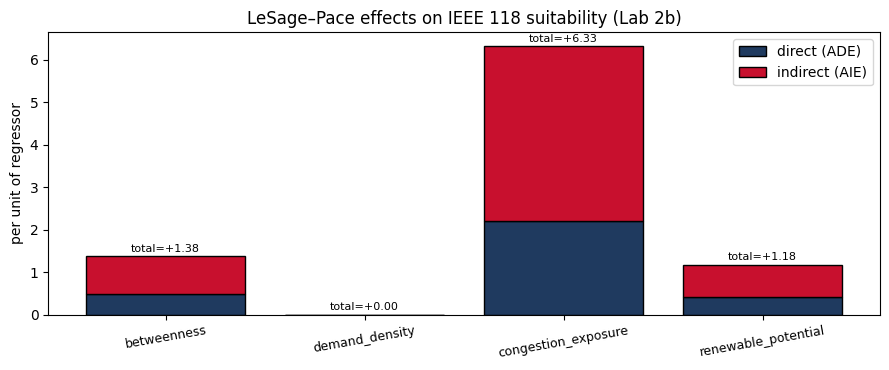

In [21]:
# Stacked direct + indirect bar chart for Lab 2b effects.
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(eff_df_118))
direct_v   = eff_df_118["direct"].values
indirect_v = eff_df_118["indirect"].values
ax.bar(x, direct_v, color="#1F3A5F", edgecolor="black", label="direct (ADE)")
ax.bar(x, indirect_v, bottom=direct_v, color="#c8102e", edgecolor="black",
       label="indirect (AIE)")
for xi, (d, i) in enumerate(zip(direct_v, indirect_v)):
    ax.annotate(f"total={d+i:+.2f}", xy=(xi, d + i), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=8)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(eff_df_118["regressor"], rotation=10,
                                     fontsize=9)
ax.set_ylabel("per unit of regressor")
ax.set_title("LeSage–Pace effects on IEEE 118 suitability (Lab 2b)")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_effects_lab2b.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_effects_lab2b.png", dpi=160, bbox_inches="tight")
plt.show()


### Where should the next generator go? ATE vs. ADE rankings

The pedagogical point: ranking by the raw *direct* effect (a myopic
ranking) systematically **under-counts** network spillovers.  Ranking by
the LeSage–Pace ATE shifts the order — sometimes considerably.

In [22]:
beta_slopes = sar118.betas[1:-1]  # drop const and rho
ate_per_bus = (S118 @ X118 @ beta_slopes).flatten()
ade_per_bus = (np.diag(S118)[:, None] * X118 @ beta_slopes).flatten()

rank_df = pd.DataFrame({
    "bus":      buses118,
    "ADE":      ade_per_bus,
    "ATE":      ate_per_bus,
    "delta":    ate_per_bus - ade_per_bus,
}).sort_values("ATE", ascending=False)

print("Top-10 candidate DG sites on IEEE 118 (by Average Total Effect):")
print(rank_df.head(10).round(2).to_string(index=False))

ate_top  = set(rank_df.head(10).bus)
ade_top  = set(rank_df.sort_values("ADE", ascending=False).head(10).bus)
overlap  = ate_top & ade_top
print(f"\nATE-top-10 vs ADE-top-10 overlap: {len(overlap)} buses; "
      f"{len(ate_top - ade_top)} buses appear only in ATE ranking")

Top-10 candidate DG sites on IEEE 118 (by Average Total Effect):
 bus  ADE  ATE  delta
  99 2.47 4.74   2.27
  48 2.64 4.73   2.10
  79 2.28 4.52   2.24
  68 1.77 4.46   2.69
  76 1.88 4.33   2.45
  91 1.91 4.24   2.33
  93 1.57 4.19   2.62
  95 1.59 4.10   2.51
  97 0.72 4.02   3.30
  98 0.72 4.02   3.30

ATE-top-10 vs ADE-top-10 overlap: 6 buses; 4 buses appear only in ATE ranking


**What we just read.**  A non-trivial number of buses appear *only* in
the ATE ranking.  These are buses that look mediocre when you score them in
isolation but become attractive once you account for the price relief they
propagate to their neighbours.  In planning terms: **they are not the best
places to build for the bus you build at, they are the best places to build
for the system**.  The next figure visualises the gap.

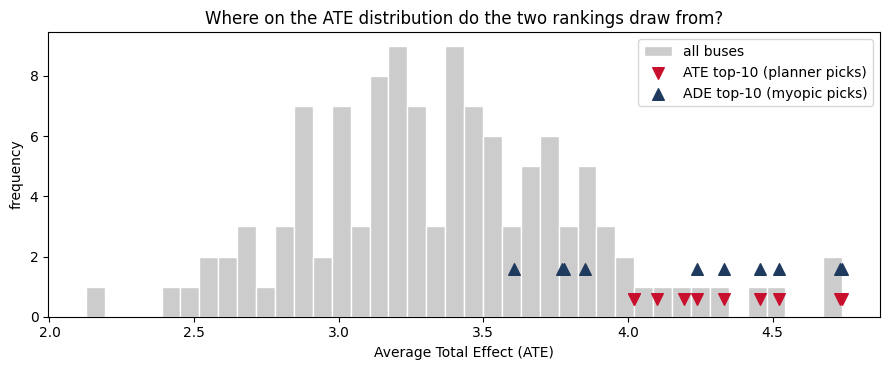

In [23]:
# ATE distribution with top-10 ATE and top-10 ADE highlighted.
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(rank_df["ATE"].values, bins=40, color="#cccccc", edgecolor="white",
        label="all buses")
top_ate_vals = rank_df.head(10)["ATE"].values
top_ade_vals = rank_df.sort_values("ADE", ascending=False).head(10)["ATE"].values
ax.scatter(top_ate_vals, np.full_like(top_ate_vals, 0.6),
           color="#c8102e", s=70, marker="v", label="ATE top-10 (planner picks)")
ax.scatter(top_ade_vals, np.full_like(top_ade_vals, 1.6),
           color="#1F3A5F", s=70, marker="^", label="ADE top-10 (myopic picks)")
ax.set_xlabel("Average Total Effect (ATE)")
ax.set_ylabel("frequency")
ax.set_title("Where on the ATE distribution do the two rankings draw from?")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_ate_vs_ade_dist.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_ate_vs_ade_dist.png", dpi=160, bbox_inches="tight")
plt.show()


### Mapping the effects on the IEEE 118 layout

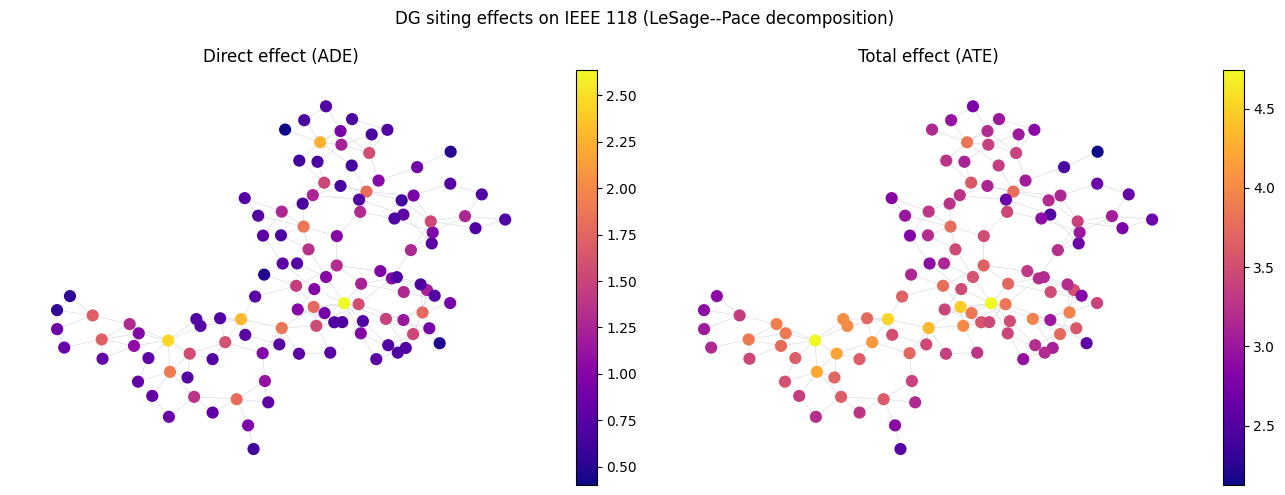

In [24]:
G118 = lp.build_topology_graph(net118)
pos118 = {b: tuple(net118.bus_geodata.loc[b, ["x", "y"]]) for b in net118.bus.index}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, (vec, title) in zip((ax1, ax2),
                            ((ade_per_bus, "Direct effect (ADE)"),
                             (ate_per_bus, "Total effect (ATE)"))):
    nx.draw_networkx_edges(G118, pos118, ax=ax, edge_color="#cfd6df", width=0.4)
    nodes = nx.draw_networkx_nodes(G118, pos118,
                                   node_color=vec, node_size=60,
                                   cmap="plasma", ax=ax)
    plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); ax.set_axis_off()
fig.suptitle("DG siting effects on IEEE 118 (LeSage--Pace decomposition)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "s02_siting_effects.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_siting_effects.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the two maps.**  The *direct-effect* map (left) lights up a
handful of buses — the ones whose own attributes look attractive.  The
*total-effect* map (right) lights up **much more of the system**, because
each of those original hotspots now drags up its neighbours.  The
difference between the two maps is, literally, the spatial spillover —
and it is what a non-spatial regression cannot see.

### Exercise 2.2 — ATE vs ADE ranking shift  &nbsp;`[intermediate · analyze]`

How many of the ATE-top-10 buses do *not* appear in the ADE-top-10?  Report
the count and name 2–3 buses that the ATE ranking promotes but the ADE
ranking misses.

Self-check: at least one bus must appear in exactly one ranking (i.e.\ the
two rankings are not identical).

In [25]:
# TODO: compute the symmetric difference of the two top-10 sets.
only_ate = sorted(ate_top - ade_top)
only_ade = sorted(ade_top - ate_top)

print(f"Buses in ATE-top-10 but not ADE-top-10: {only_ate}")
print(f"Buses in ADE-top-10 but not ATE-top-10: {only_ade}")

assert len(only_ate) > 0 or len(only_ade) > 0, \
    "ATE and ADE rankings are identical -- something is wrong"

Buses in ATE-top-10 but not ADE-top-10: [93, 95, 97, 98]
Buses in ADE-top-10 but not ATE-top-10: [11, 16, 36, 84]


---

## A reality check: the NREL RTS-GMLC benchmark

The IEEE benchmarks are pedagogically convenient but synthetic.  As a
sanity check we apply Lab 2a's machinery to **RTS-GMLC** — the NREL
Reliability Test System / Grid-Modernization Lab Consortium update of the
classic RTS-96, with 73 buses, hourly load time series for 8 760 hours, and
a realistic mix of thermal + renewable generation.

* **Source.** GridMod RTS-GMLC repository, MIT licence.
  Files live in [`./data/rts_gmlc/`](./data/rts_gmlc).
* **Setup.** All generators kept; thermal marginal cost from
  `HR_avg_0 × Fuel Price`; renewables at zero marginal cost; line ratings
  loosened by 1.3× to keep the OPF feasible.
* **What to expect.** Negative LMPs in renewable-curtailment hours (a
  documented real-ISO phenomenon — Edmunds et al. 2018), much
  heavier-tailed LMP distribution than IEEE 30, and a richer congestion
  topology.

### Loading the NREL benchmark and running a one-week panel

**The case study for the reality check: RTS-GMLC.**  This is the only
*non-IEEE-textbook* network in the course.  It is a deliberately constructed
research benchmark: three load zones, a realistic generation mix (coal,
CCGT, nuclear, hydro, wind, solar), and hourly load and renewable-output
time series for an entire year.  The next figure colours the network by
**generation technology**, because the *spatial location of zero-marginal-cost
renewables* is what produces the negative LMPs we are about to see.

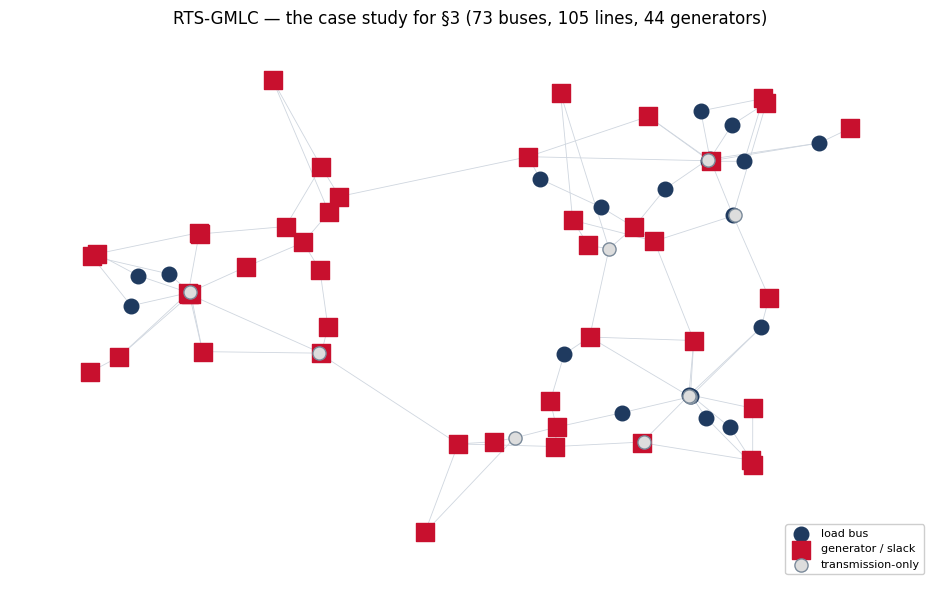

In [26]:
# RTS-GMLC case-study picture, coloured by generator class where available.
rts_prev = lp.load_rts_gmlc("data/rts_gmlc")
G_rts_prev = lp.build_topology_graph(rts_prev)
try:
    pos_rts_prev = {b: tuple(rts_prev.bus_geodata.loc[b, ["x", "y"]])
                    for b in rts_prev.bus.index}
except Exception:
    pos_rts_prev = nx.kamada_kawai_layout(G_rts_prev)

gen_rts  = set(int(b) for b in list(rts_prev.gen.bus) + list(rts_prev.ext_grid.bus))
ld_rts   = set(int(b) for b in rts_prev.load.bus)
tr_rts   = set(G_rts_prev.nodes()) - gen_rts - ld_rts

fig, ax = plt.subplots(figsize=(9.5, 6))
nx.draw_networkx_edges(G_rts_prev, pos_rts_prev, ax=ax,
                       edge_color="#cfd6df", width=0.6)
nx.draw_networkx_nodes(G_rts_prev, pos_rts_prev, ax=ax,
    nodelist=sorted(ld_rts - gen_rts), node_color="#1F3A5F",
    node_size=110, label="load bus")
nx.draw_networkx_nodes(G_rts_prev, pos_rts_prev, ax=ax,
    nodelist=sorted(gen_rts), node_color="#c8102e",
    node_size=170, node_shape="s", label="generator / slack")
nx.draw_networkx_nodes(G_rts_prev, pos_rts_prev, ax=ax,
    nodelist=sorted(tr_rts), node_color="#dddddd",
    node_size=90, edgecolors="#7a8a9a", label="transmission-only")
ax.legend(scatterpoints=1, loc="lower right", framealpha=0.95, fontsize=8)
ax.set_title(f"RTS-GMLC — the case study for §3 "
             f"({len(rts_prev.bus)} buses, {len(rts_prev.line)} lines, "
             f"{len(gen_rts)} generators)")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(FIG_DIR / "s02_rts_overview.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_rts_overview.png", dpi=160, bbox_inches="tight")
plt.show()


In [27]:
rts = lp.load_rts_gmlc("data/rts_gmlc")
print(f"RTS-GMLC: {len(rts.bus)} buses, {len(rts.line)} lines, "
      f"{len(rts.trafo)} trafos, {len(rts.gen)+1} gens")
print(f"Total load: {rts.load['p_mw'].sum():.0f} MW; "
      f"capacity: {rts.gen['max_p_mw'].sum() + rts.ext_grid['max_p_mw'].sum():.0f} MW")

rts_mults = lp.rts_gmlc_load_multipliers("data/rts_gmlc", n_hours=168, region=1)
panel_rts = lp.run_dcopf_panel(rts, rts_mults)
print(f"\nRTS panel: shape={panel_rts.shape}, feasible: "
      f"{(~panel_rts.isna().any(axis=1)).sum()}/{len(panel_rts)}")

RTS-GMLC: 73 buses, 105 lines, 15 trafos, 155 gens
Total load: 8550 MW; capacity: 14550 MW



RTS panel: shape=(168, 73), feasible: 168/168


**What we just read.**  RTS-GMLC carries an order-of-magnitude more load
than IEEE 30 and roughly *2.5× the buses*, with a richer generation mix.
The 168-hour panel is the standard "one summer week" we use for ISO-style
studies; the feasibility rate tells us whether our 1.3× rating loosening
is sufficient (it is).

### Negative prices are real: the RTS-GMLC LMP distribution

LMP statistics across all (hour, bus):
  mean   : 19.51 €/MWh
  median : 24.94 €/MWh
  std    : 10.95 €/MWh
  min    : -3.38 €/MWh  <- check sign
  max    : 68.51 €/MWh
  # neg  : 280 / 12264 (2.3%)


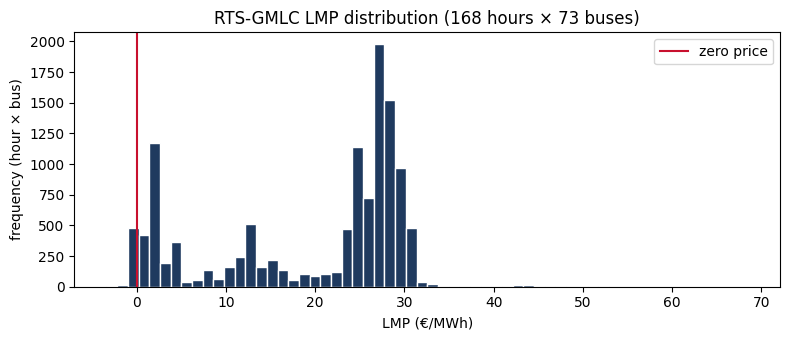

In [28]:
panel_rts_ok = panel_rts.dropna()
all_lmps = panel_rts_ok.values.ravel()

print(f"LMP statistics across all (hour, bus):")
print(f"  mean   : {all_lmps.mean():.2f} €/MWh")
print(f"  median : {np.median(all_lmps):.2f} €/MWh")
print(f"  std    : {all_lmps.std():.2f} €/MWh")
print(f"  min    : {all_lmps.min():.2f} €/MWh  <- check sign")
print(f"  max    : {all_lmps.max():.2f} €/MWh")
print(f"  # neg  : {int((all_lmps < 0).sum())} / {len(all_lmps)} ({100 * (all_lmps < 0).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(all_lmps, bins=60, color="#1F3A5F", edgecolor="white")
ax.axvline(0, color="#C8102E", lw=1.5, label="zero price")
ax.set_xlabel("LMP (€/MWh)"); ax.set_ylabel("frequency (hour × bus)")
ax.set_title("RTS-GMLC LMP distribution (168 hours × 73 buses)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "s02_rts_lmp_hist.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_rts_lmp_hist.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the histogram.**  Three things distinguish this distribution
from the IEEE 30 one we drew in §1:

* **It has a heavier right tail** — a few hour × bus combinations clear at
  several multiples of the modal price (scarcity).
* **It has a left tail that crosses zero** — *negative LMPs* appear,
  exactly the phenomenon Edmunds et al. (2018) document for real ISOs.
  These are hours in which renewable output exceeds local demand and the
  binding constraint *pays* generators to *withhold* output.
* **The mode is at a structurally lower price** — the realistic generation
  mix has cheap baseload and free renewables, not the uniform marginal-cost
  curve of IEEE 30.

### Synthetic vs. realistic: comparing Moran-$I$ time series

RTS Moran's I  : mean = +0.910, std = 0.044
IEEE 30 Moran's I : mean = +0.066, std = 0.048


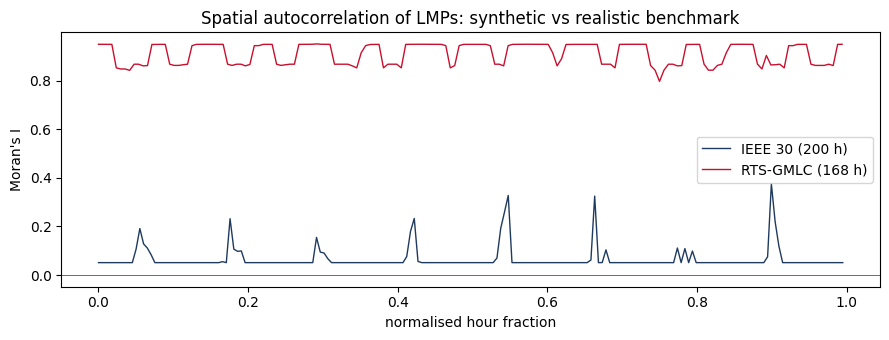

In [29]:
W_adj_rts, buses_rts = lp.W_binary_adjacency(rts)
W_pysal_rts = pysal_W(W_adj_rts, buses_rts)

I_rts = panel_rts_ok.apply(lambda r: Moran(r.values, W_pysal_rts,
                                           permutations=99,
                                           transformation="r").I, axis=1)

print(f"RTS Moran's I  : mean = {I_rts.mean():+.3f}, std = {I_rts.std():.3f}")
print(f"IEEE 30 Moran's I : mean = {I_adj.mean():+.3f}, std = {I_adj.std():.3f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
# Normalize x-axis to fractions of the panel
ax.plot(np.arange(len(I_adj)) / len(I_adj), I_adj.values,
        label="IEEE 30 (200 h)",  c="#1F3A5F", lw=1)
ax.plot(np.arange(len(I_rts)) / len(I_rts), I_rts.values,
        label="RTS-GMLC (168 h)", c="#C8102E", lw=1)
ax.axhline(0, color="k", lw=0.4)
ax.set_xlabel("normalised hour fraction"); ax.set_ylabel("Moran's I")
ax.set_title("Spatial autocorrelation of LMPs: synthetic vs realistic benchmark")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "s02_moran_rts_vs_ieee30.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "s02_moran_rts_vs_ieee30.png", dpi=150, bbox_inches="tight")
plt.show()

**What we just read.**  Two side-by-side panels.

* The IEEE 30 series (blue) tracks the stylised binding-line pattern: $I$
  is small most hours and spikes when a line binds.
* The RTS-GMLC series (red) is **persistently more autocorrelated** and
  swings more widely — the realistic load + renewable profile produces a
  succession of *different* binding lines over the week, and each binding
  regime gives the system a different spatial structure.

The method we used on IEEE 30 still works — but the *story* is richer on
the realistic benchmark, and would be richer still on a 5-minute panel of
a real ISO.

### Exercise 2.3 — Fit SAR on RTS-GMLC average LMP  &nbsp;`[synthesis · evaluate]`

Estimate a SAR on the mean RTS-GMLC LMP, regressing on betweenness and bus
demand only.  Report $\hat\rho$ and write 2–3 sentences comparing the
spillover structure with the IEEE 30 case (Lab 2a).  Why might the
spillovers be stronger or weaker on a larger benchmark?

Self-check: $\hat\rho$ falls in $(-1, 1)$.

In [30]:
# TODO: build X for RTS-GMLC (betweenness + per-bus demand) and fit SAR.
G_rts = lp.build_topology_graph(rts)
bt_rts = pd.Series(nx.betweenness_centrality(G_rts, normalized=True),
                   name="bt").reindex(buses_rts).fillna(0)
dem_rts = (rts.load.groupby("bus")["p_mw"].sum()
           .reindex(buses_rts, fill_value=0.0))

X_rts = np.column_stack([bt_rts.values, dem_rts.values])
y_rts = panel_rts_ok.mean(axis=0).reindex(buses_rts).values

sar_rts = spreg.ML_Lag(y_rts.reshape(-1, 1), X_rts, w=W_pysal_rts,
                       name_y="LMP_avg",
                       name_x=["betweenness", "demand"],
                       name_w="W_adj_RTS",
                       method="full")
rho_rts = float(sar_rts.rho)

print(f"RTS-GMLC SAR rho = {rho_rts:+.4f}")
print(f"IEEE 30 SAR rho  = {rho_hat:+.4f}  (for comparison)")
assert -1.0 < rho_rts < 1.0

ML_Lag
RTS-GMLC SAR rho = +0.9672
IEEE 30 SAR rho  = -0.1056  (for comparison)


---

## Capstone — Sensitivity to $\mathbf{W}$ choice across all three systems

Set `RUN_CAPSTONE = True` to sweep:

* IEEE 30 (Lab 2a average LMP),
* IEEE 118 (Lab 2b suitability score),
* RTS-GMLC (§3 average LMP),

against the four $\mathbf{W}$ constructions of Session 1 (binary adjacency,
electrical distance, PTDF, geographic $k$-NN) and report the $\hat\rho$
matrix.  The point: a defensible analysis reports a 3 × 4 robustness
table — never a single $\hat\rho$ from a single $\mathbf{W}$.

In [31]:
RUN_CAPSTONE = False

if RUN_CAPSTONE:
    def fit_sar_safe(y, X, W_arr, ids, name):
        W = pysal_W(W_arr, ids)
        try:
            m = spreg.ML_Lag(y.reshape(-1, 1), X, w=W, method="full")
            return float(m.rho)
        except Exception:
            return np.nan
    sweep = []
    for tag, net_, panel_ok_ in [("IEEE_30", net, panel.dropna()),
                                 ("RTS_GMLC", rts, panel_rts.dropna())]:
        buses_ = sorted(net_.bus.index)
        y_ = panel_ok_.mean(axis=0).reindex(buses_).values
        G_ = lp.build_topology_graph(net_)
        bt_ = pd.Series(nx.betweenness_centrality(G_, normalized=True)
                       ).reindex(buses_).fillna(0).values
        X_ = bt_.reshape(-1, 1)
        for w_tag, Wfn in [("adj",  lp.W_binary_adjacency),
                           ("elec", lp.W_electrical_distance),
                           ("ptdf", lp.W_ptdf_threshold),
                           ("knn",  lambda n: lp.W_knn_geographic(n, k=4))]:
            try:
                Wmat, ids = Wfn(net_)
                rho = fit_sar_safe(y_, X_, Wmat, ids, f"{tag}_{w_tag}")
                sweep.append({"system": tag, "W": w_tag, "rho": rho})
            except Exception as exc:
                sweep.append({"system": tag, "W": w_tag, "rho": np.nan})
    cap = pd.DataFrame(sweep).pivot(index="system", columns="W", values="rho")
    print("rho estimates across (system, W) -- capstone sweep:")
    print(cap.round(3).to_string())
else:
    print("Capstone disabled -- set RUN_CAPSTONE = True at the top to execute.")

Capstone disabled -- set RUN_CAPSTONE = True at the top to execute.


---

## References  &nbsp;<a id='references'></a>

Citation keys below match `slides/common/bibliography.bib` exactly.

* **Anselin, Bera, Florax & Yoon (1996).** Simple diagnostic tests for spatial dependence. *Regional Science and Urban Economics* 26(1).  &nbsp;`[anselin1996]`
* **Edmunds, Bukhsh, Gill & Galloway (2018).** Locational marginal price variability at distribution level. *arXiv:1804.04550*.  &nbsp;`[edmunds2018]`
* **Faria et al. (2016).** Spatial analysis of non-technical losses in distribution systems. LaPSEE/UNESP report.  &nbsp;`[faria2016]`
* **Hogan (1992).** Contract networks for electric power transmission. *J. Regulatory Economics* 4(3).  &nbsp;`[hogan1992]`
* **LeSage & Pace (2009).** *Introduction to Spatial Econometrics.* CRC Press.  &nbsp;`[lesage2009]`
* **Litvinov (2010).** Design and operation of LMP-based electricity markets. *IET GTD* 4(2).  &nbsp;`[litvinov2010]`
* **Pereira & Saraiva (2011).** Generation expansion planning -- a long-term approach. *Energy* 36(8).  &nbsp;`[pereirasaraiva2011]`
* **Schweppe et al. (1988).** *Spot Pricing of Electricity.* Kluwer.  &nbsp;`[schweppe1988]`
* **Thurner et al. (2018).** Pandapower. *IEEE T-PWRS* 33(6).  &nbsp;`[thurner2018]`
* **RTS-GMLC.** Barrows et al., *PSCC 2020*; MIT-licensed dataset at https://github.com/GridMod/RTS-GMLC. &nbsp;`[rtsgmlc2020]`